Understanding customer preferences and restaurant trends is important for making informed business decisions in food industry. In this article, we will analyze Zomato’s restaurant dataset using Python to find meaningful insights. We aim to answer questions such as:

Do more restaurants provide online delivery compared to offline services?
Which types of restaurants are most favored by the general public?
What price range do couples prefer for dining out?

In [ ]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns


### STEP1 EXPLORATORY DATA ANALYSIS

In [12]:
df=pd.read_csv("Zomato-data.csv")
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


In [3]:
df.shape

(148, 7)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   name                         148 non-null    str  
 1   online_order                 148 non-null    str  
 2   book_table                   148 non-null    str  
 3   rate                         148 non-null    str  
 4   votes                        148 non-null    int64
 5   approx_cost(for two people)  148 non-null    int64
 6   listed_in(type)              148 non-null    str  
dtypes: int64(2), str(5)
memory usage: 8.2 KB


In [5]:
df.isnull().sum()

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [22]:
df.describe()

,rate,votes,approx_cost(for two people)
count,148.000000,148.000000,148.000000
mean,3.633108,264.810811,418.243243
std,0.402271,653.676951,223.085098
min,2.600000,0.000000,100.000000
25%,3.300000,6.750000,200.000000
50%,3.700000,43.500000,400.000000
75%,3.900000,221.750000,600.000000
max,4.600000,4884.000000,950.000000


### STEP2: CLEANING THE DATA

In [20]:
"""
Are there missing values?
Are there duplicate rows?
Are data types correct?
"""
# converting rate to float to perform arithmetic oprations easily 
df["rate"]=df["rate"].str.split("/").str[0].astype("float")
df.head()


,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


### STEP3: UNDERSTAND EVERY COLUMN

In [ ]:
df["online_order"].value_counts()  # so this means less restaurants provide online order 

online_order
No     90
Yes    58
Name: count, dtype: int64

In [ ]:
df["book_table"].value_counts()   # so very less restaurants reserve the table in advance

book_table
No     140
Yes      8
Name: count, dtype: int64

In [ ]:
df["rate"].min()  # min rating

np.float64(2.6)

In [19]:
df["rate"].max()   # max rating

np.float64(4.6)

In [ ]:
df["rate"].mean()  # avg rating

np.float64(3.6331081081081082)

In [25]:
df["listed_in(type)"].value_counts()

listed_in(type)
Dining    110
Cafes      23
other       8
Buffet      7
Name: count, dtype: int64

In [25]:
grouped_data=df.groupby("listed_in(type)")

In [26]:
for keys,data in grouped_data:
    print("key:",keys)
    print(data)

key: Buffet
                                              name online_order book_table  rate  votes  approx_cost(for two people) listed_in(type)
0                                            Jalsa          Yes        Yes   4.1    775                          800          Buffet
1                                   Spice Elephant          Yes         No   4.1    787                          800          Buffet
2                                  San Churro Cafe          Yes         No   3.8    918                          800          Buffet
3                            Addhuri Udupi Bhojana           No         No   3.7     88                          300          Buffet
4                                    Grand Village           No         No   3.8    166                          600          Buffet
5                                  Timepass Dinner          Yes         No   3.8    286                          600          Buffet
6  Rosewood International Hotel - Bar & Restaurant       

In [33]:
grouped_data["votes"].sum()

listed_in(type)
Buffet     3028
Cafes      6434
Dining    20363
other      9367
Name: votes, dtype: int64

In [27]:
grouped_data["votes"].max()

listed_in(type)
Buffet     918
Cafes     2556
Dining    4401
other     4884
Name: votes, dtype: int64

In [28]:
grouped_data.describe()

rate                                                  votes                                                               approx_cost(for two people)                                                           
                 count      mean       std  min    25%  50%   75%  max  count         mean          std   min    25%    50%     75%     max                       count        mean         std    min    25%    50%    75%    max
listed_in(type)                                                                                                                                                                                                                   
Buffet             7.0  3.842857  0.190238  3.6  3.750  3.8  3.95  4.1    7.0   432.571429   380.799972   8.0  127.0  286.0   781.0   918.0                         7.0  671.428571  188.982237  300.0  600.0  800.0  800.0  800.0
Cafes             23.0  3.765217  0.391511  3.0  3.600  3.8  4.00  4.6   23.0   279.739130   539.113010   4.0   46.5  133.0   199.5  2556.0                        23.0  545.652174  165.771642  200.0  475.0  550.0  600.0  900.0
Dining           110.0  3.571818  0.373707  2.6  3.300  3.6  3.80  4.4  110.0   185.118182   506.249544   0.0    0.0   28.0   123.5  4401.0                       110.0  357.272727  206.748125  100.0  200.0  300.0  450.0  950.0
other              8.0  3.912500  0.679154  2.8  3.725  4.2  4.25  4.6    8.0  1170.875000  1696.389059  84.0  304.0  384.5  1018.5  4884.0                         8.0  668.750000  122.292098  500.0  575.0  700.0  762.5  800.0

In [29]:
df["listed_in(type)"].unique()

<StringArray>
['Buffet', 'Cafes', 'other', 'Dining']
Length: 4, dtype: str

In [30]:
df["listed_in(type)"].nunique()

4

### STEP4: ANSWER THE BUSINESS QUESTIONS

Question 1
Do more restaurants provide online delivery compared to offline services?

In [42]:
counts=df["online_order"].value_counts()  

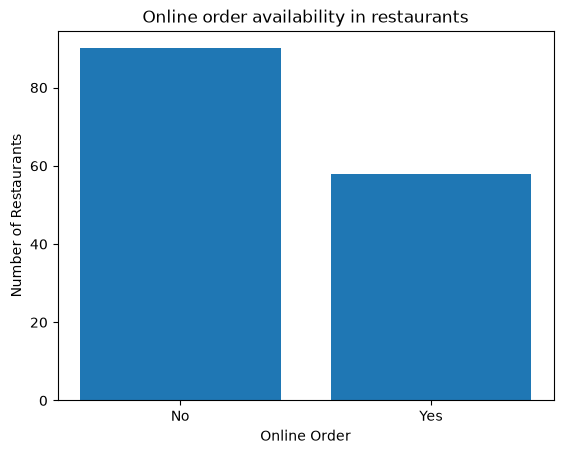

In [40]:
plt.bar(counts.index,counts.values)
plt.title("Online order availability in restaurants")
plt.xlabel("Online Order")
plt.ylabel("Number of Restaurants")
plt.show()

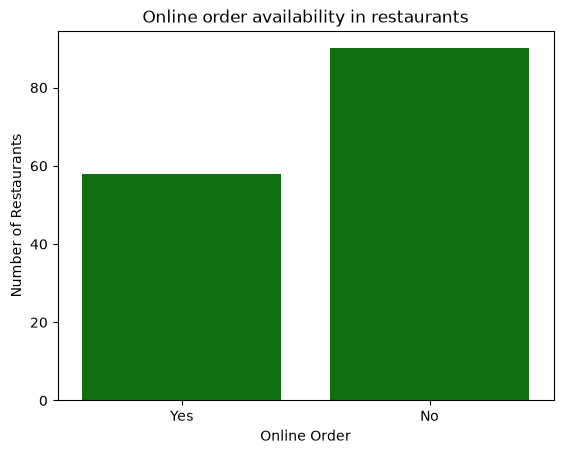

In [68]:
# or we can do this using sns countplot 
sns.countplot(x=df["online_order"],color="Green")
plt.title("Online order availability in restaurants")
plt.xlabel("Online Order")
plt.ylabel("Number of Restaurants")
plt.show()

The analysis indicates that a smaller number of restaurants offer online ordering, while the majority do not provide this service.

Question 2

Which restaurant types are most popular?

In [ ]:
# Most common resturant types 
type_count=df["listed_in(type)"].value_counts().sort_values()
type_count

listed_in(type)
Buffet      7
other       8
Cafes      23
Dining    110
Name: count, dtype: int64

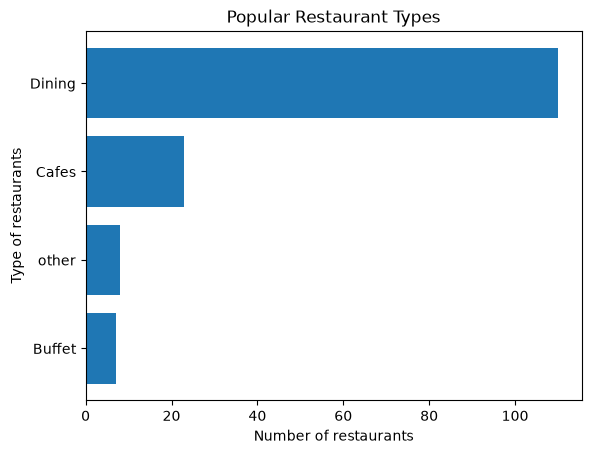

In [71]:
plt.barh(y=type_count.index,width=type_count.values)
plt.ylabel("Type of restaurants")
plt.xlabel("Number of restaurants")
plt.title("Popular Restaurant Types")
plt.show()

So this analysis shows that among restaurant types dining is more popular.

In [99]:
# Most favored based on ratings
g=df.groupby(df["listed_in(type)"])
g["votes"].sum().sort_values()

listed_in(type)
Buffet     3028
Cafes      6434
other      9367
Dining    20363
Name: votes, dtype: int64

Question 3

What price range do couples prefer?

In [72]:
df["approx_cost(for two people)"]

0      800
1      800
2      800
3      300
4      600
      ... 
143    100
144    150
145    450
146    800
147    200
Name: approx_cost(for two people), Length: 148, dtype: int64

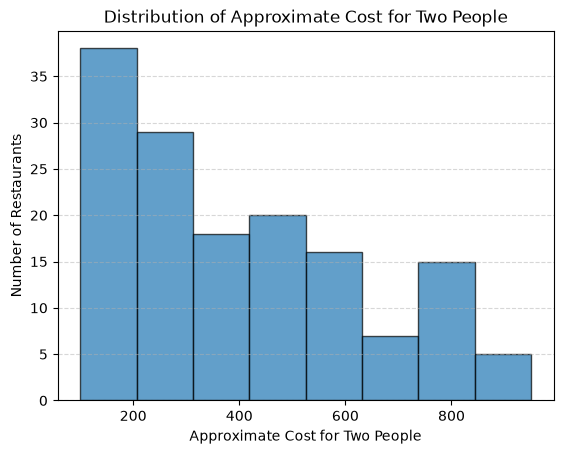

In [92]:
# plt.figure(edgecolor="Black",layout='constrained')
plt.hist(df["approx_cost(for two people)"],8,edgecolor='black',alpha=0.7)
plt.title("Distribution of Approximate Cost for Two People")
plt.xlabel("Approximate Cost for Two People")
plt.ylabel("Number of Restaurants")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

The histogram shows that most restaurants have an approximate dining cost between 100 and 300 for two people. As the cost increases, the number of restaurants decreases. This indicates that the dataset contains more budget and mid-range restaurants than premium-priced restaurants.However, the dataset does not contain customer visit data, so it cannot directly determine couples' actual preferences.